# Análisis de Componentes Principales (PCA)
## Actividades Parte 1 y Parte 2

---
Este notebook implementa PCA en dos actividades:
- **Parte 1:** Dataset 3D → reducción a 2D y 1D
- **Parte 2:** Dataset de alta dimensionalidad → reducción a k componentes principales

**Autor:** Estudiante  
**Herramienta de apoyo:** IA (Claude)


## Instalación e importación de librerías

In [ ]:
# Instalación de dependencias necesarias
!pip install scikit-learn matplotlib seaborn pandas numpy --quiet

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.datasets import load_iris, load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from mpl_toolkits.mplot3d import Axes3D

# Configuración global de gráficas
plt.rcParams.update({
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor':   '#1a1a2e',
    'axes.edgecolor':   '#444466',
    'axes.labelcolor':  '#e0e0ff',
    'xtick.color':      '#aaaacc',
    'ytick.color':      '#aaaacc',
    'text.color':       '#e0e0ff',
    'grid.color':       '#2a2a4a',
    'grid.linewidth':   0.6,
    'legend.facecolor': '#1a1a2e',
    'legend.edgecolor': '#444466',
    'font.family':      'DejaVu Sans',
    'font.size':        11,
})

PALETTE   = ['#7f5af0', '#2cb67d', '#ff8906', '#e53170', '#3da9fc']
PALETTE3  = ['#7f5af0', '#2cb67d', '#ff8906']

print('Librerías cargadas correctamente')

Librerías cargadas correctamente


---
# PARTE 1 — Dataset 3D → Reducción a 2D y 1D
## Dataset: Iris (3 características seleccionadas)

### Carga y exploración del dataset

In [ ]:
# --- Carga del dataset Iris ---
iris = load_iris()

# Seleccionamos 3 características para poder graficar en 3D
# sepal length, petal length, petal width
feature_idx  = [0, 2, 3]
feature_names = [iris.feature_names[i] for i in feature_idx]

X_p1_raw = iris.data[:, feature_idx]   # shape (150, 3)
y_p1     = iris.target
classes  = iris.target_names

df_p1 = pd.DataFrame(X_p1_raw, columns=feature_names)
df_p1['Species'] = [classes[i] for i in y_p1]

print('═' * 55)
print('  DATASET: IRIS  (3 características seleccionadas)')
print('═' * 55)
print(f'  Muestras      : {X_p1_raw.shape[0]}')
print(f'  Características: {X_p1_raw.shape[1]}')
print(f'  Clases         : {list(classes)}')
print(f'  Distribución   : {dict(zip(*np.unique(y_p1, return_counts=True)))}')
print('═' * 55)
df_p1.describe().T

═══════════════════════════════════════════════════════
  DATASET: IRIS  (3 características seleccionadas)
═══════════════════════════════════════════════════════
  Muestras      : 150
  Características: 3
  Clases         : [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
  Distribución   : {np.int64(0): np.int64(50), np.int64(1): np.int64(50), np.int64(2): np.int64(50)}
═══════════════════════════════════════════════════════


,count,mean,std,min,25%,50%,75%,max
sepal length (cm),150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
petal length (cm),150.0,3.758000,1.765298,1.0,1.6,4.35,5.1,6.9
petal width (cm),150.0,1.199333,0.762238,0.1,0.3,1.30,1.8,2.5


### Visualización 3D original (antes de PCA)

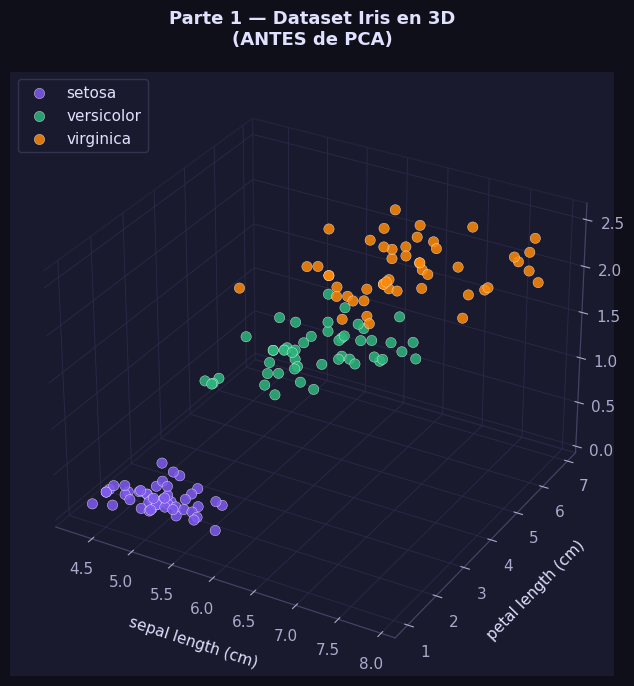

Gráfica 3D guardada


In [ ]:
fig = plt.figure(figsize=(10, 7))
fig.patch.set_facecolor('#0f0f1a')
ax  = fig.add_subplot(111, projection='3d')
ax.set_facecolor('#1a1a2e')

for i, cls in enumerate(classes):
    mask = y_p1 == i
    ax.scatter(X_p1_raw[mask, 0], X_p1_raw[mask, 1], X_p1_raw[mask, 2],
               c=PALETTE3[i], label=cls, s=55, alpha=0.85, edgecolors='white', linewidths=0.3)

ax.set_xlabel(feature_names[0], labelpad=10)
ax.set_ylabel(feature_names[1], labelpad=10)
ax.set_zlabel(feature_names[2], labelpad=10)
ax.set_title('Parte 1 — Dataset Iris en 3D\n(ANTES de PCA)', pad=20, fontsize=13, fontweight='bold')
ax.legend(loc='upper left', framealpha=0.6)
ax.tick_params(colors='#aaaacc')
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor('#2a2a4a')
ax.yaxis.pane.set_edgecolor('#2a2a4a')
ax.zaxis.pane.set_edgecolor('#2a2a4a')

plt.tight_layout()
#plt.savefig('/mnt/user-data/outputs/p1_3d_original.png', dpi=130, bbox_inches='tight')
plt.show()
print('Gráfica 3D guardada')

### Estandarización y aplicación de PCA

In [ ]:
# Estandarización (media=0, std=1) — paso OBLIGATORIO antes de PCA
scaler_p1  = StandardScaler()
X_p1_std   = scaler_p1.fit_transform(X_p1_raw)

# ─── PCA → 2D ───────────────────────────────────────────────
pca_2d    = PCA(n_components=2)
X_p1_2d   = pca_2d.fit_transform(X_p1_std)

# ─── PCA → 1D ───────────────────────────────────────────────
pca_1d    = PCA(n_components=1)
X_p1_1d   = pca_1d.fit_transform(X_p1_std)

# ─── Resumen de varianza explicada ──────────────────────────
print('╔═══════════════════════════════════════════════════╗')
print('║         VARIANZA EXPLICADA — PARTE 1              ║')
print('╠═══════════════════════════════════════════════════╣')
for i, v in enumerate(pca_2d.explained_variance_ratio_):
    print(f'║  PC{i+1}: {v*100:6.2f}%  {"█" * int(v*40)}  ║')
print(f'║  Total (2D): {pca_2d.explained_variance_ratio_.sum()*100:.2f}%')
print(f'║  Total (1D): {pca_1d.explained_variance_ratio_.sum()*100:.2f}%')
print('╚═══════════════════════════════════════════════════╝')

╔═══════════════════════════════════════════════════╗
║         VARIANZA EXPLICADA — PARTE 1              ║
╠═══════════════════════════════════════════════════╣
║  PC1:  92.32%  ████████████████████████████████████  ║
║  PC2:   6.65%  ██  ║
║  Total (2D): 98.97%
║  Total (1D): 92.32%
╚═══════════════════════════════════════════════════╝


### Gráficas después de PCA (2D y 1D)

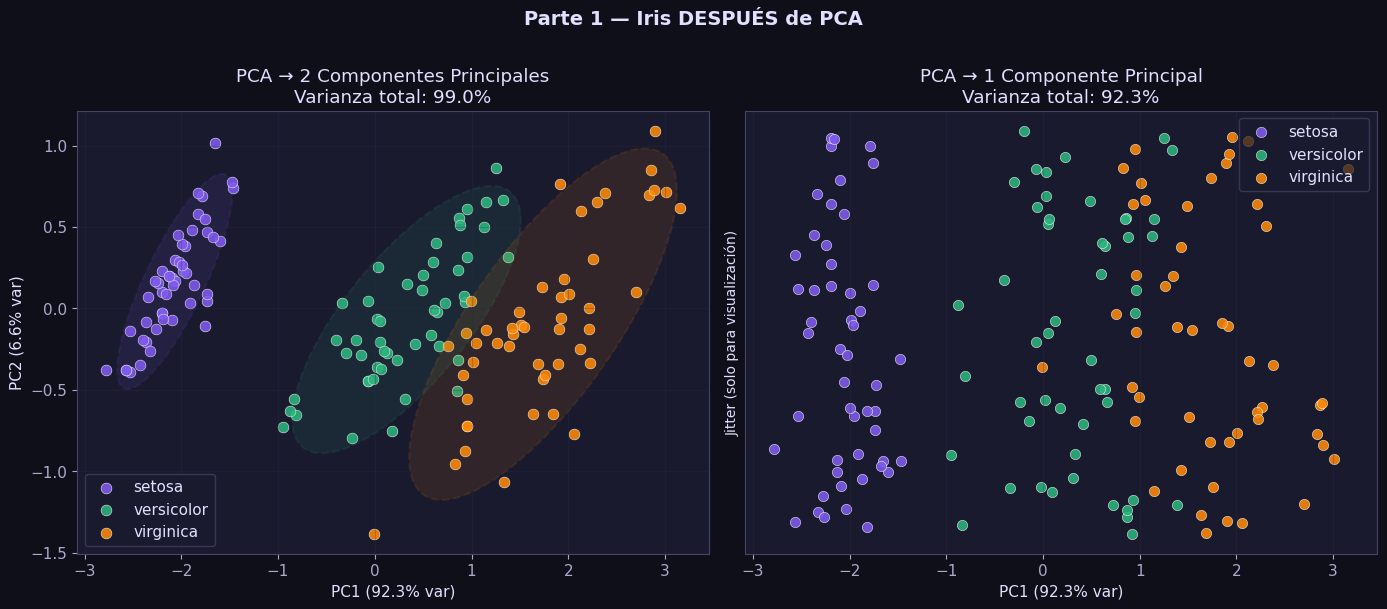

✅ Gráficas 2D y 1D guardadas


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Parte 1 — Iris DESPUÉS de PCA', fontsize=14, fontweight='bold', y=1.01)

# ─── Plot 2D ────────────────────────────────────────────────
ax1 = axes[0]
for i, cls in enumerate(classes):
    mask = y_p1 == i
    ax1.scatter(X_p1_2d[mask, 0], X_p1_2d[mask, 1],
                c=PALETTE3[i], label=cls, s=60, alpha=0.88,
                edgecolors='white', linewidths=0.4)

# Elipses de confianza (estadística)
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

def confidence_ellipse(x, y, ax, n_std=2.0, **kwargs):
    if len(x) < 2: return
    cov  = np.cov(x, y)
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    w, h  = 2 * n_std * np.sqrt(vals)
    e = Ellipse(xy=(np.mean(x), np.mean(y)), width=w, height=h,
                angle=theta, **kwargs)
    ax.add_patch(e)

for i in range(3):
    mask = y_p1 == i
    confidence_ellipse(X_p1_2d[mask, 0], X_p1_2d[mask, 1], ax1,
                       edgecolor=PALETTE3[i], facecolor=PALETTE3[i],
                       alpha=0.10, linewidth=1.5, linestyle='--')

ax1.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% var)', fontsize=11)
ax1.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% var)', fontsize=11)
ax1.set_title('PCA → 2 Componentes Principales\n'
              f'Varianza total: {pca_2d.explained_variance_ratio_.sum()*100:.1f}%')
ax1.legend(framealpha=0.7)
ax1.grid(True, alpha=0.3)

# ─── Plot 1D ────────────────────────────────────────────────
ax2 = axes[1]
jitter = np.random.RandomState(42).uniform(-0.25, 0.25, size=len(X_p1_1d))
for i, cls in enumerate(classes):
    mask = y_p1 == i
    ax2.scatter(X_p1_1d[mask, 0], jitter[mask],
                c=PALETTE3[i], label=cls, s=55, alpha=0.88,
                edgecolors='white', linewidths=0.4)

ax2.set_xlabel(f'PC1 ({pca_1d.explained_variance_ratio_[0]*100:.1f}% var)', fontsize=11)
ax2.set_ylabel('Jitter (solo para visualización)', fontsize=10)
ax2.set_title('PCA → 1 Componente Principal\n'
              f'Varianza total: {pca_1d.explained_variance_ratio_.sum()*100:.1f}%')
ax2.legend(framealpha=0.7)
ax2.grid(True, alpha=0.3)
ax2.set_yticks([])

plt.tight_layout()
#plt.savefig('/mnt/user-data/outputs/p1_pca_resultado.png', dpi=130, bbox_inches='tight')
plt.show()
print('✅ Gráficas 2D y 1D guardadas')

### Gráfica de varianza explicada acumulada

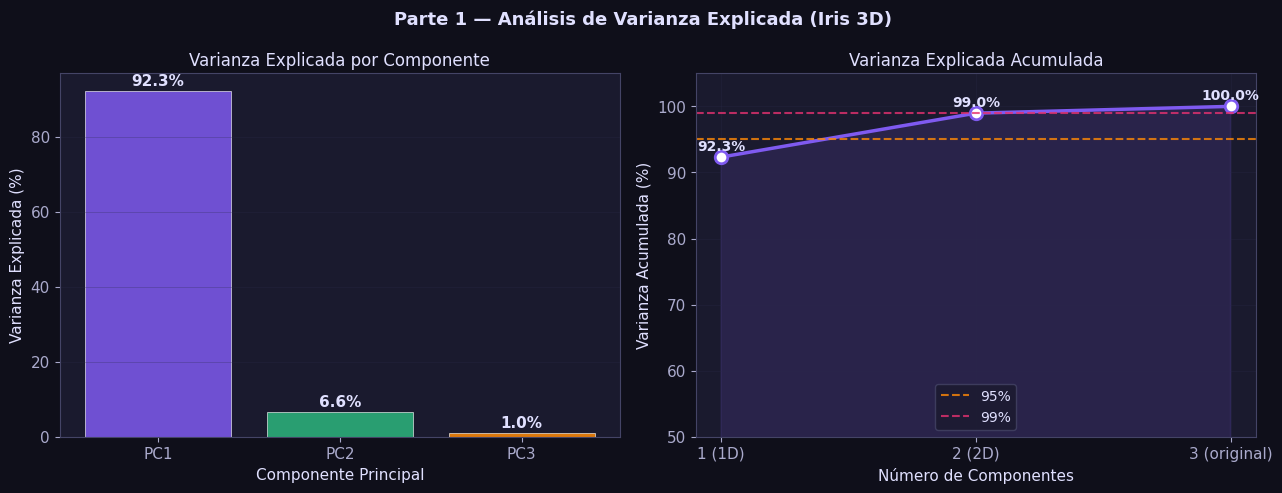

In [ ]:
pca_full = PCA(n_components=3)
pca_full.fit(X_p1_std)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Varianza por componente
ax1 = axes[0]
bars = ax1.bar(range(1, 4), pca_full.explained_variance_ratio_ * 100,
               color=PALETTE3, alpha=0.85, edgecolor='white', linewidth=0.5)
for bar, v in zip(bars, pca_full.explained_variance_ratio_):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{v*100:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax1.set_xlabel('Componente Principal', fontsize=11)
ax1.set_ylabel('Varianza Explicada (%)', fontsize=11)
ax1.set_title('Varianza Explicada por Componente', fontsize=12)
ax1.set_xticks([1, 2, 3])
ax1.set_xticklabels(['PC1', 'PC2', 'PC3'])
ax1.grid(True, axis='y', alpha=0.3)

# Varianza acumulada
ax2 = axes[1]
cum_var = np.cumsum(pca_full.explained_variance_ratio_) * 100
ax2.plot([1, 2, 3], cum_var, 'o-', color='#7f5af0', linewidth=2.5,
         markersize=9, markerfacecolor='white', markeredgewidth=2)
ax2.fill_between([1, 2, 3], cum_var, alpha=0.15, color='#7f5af0')
ax2.axhline(95, color='#ff8906', linestyle='--', linewidth=1.5, alpha=0.8, label='95%')
ax2.axhline(99, color='#e53170', linestyle='--', linewidth=1.5, alpha=0.8, label='99%')
for x, v in zip([1, 2, 3], cum_var):
    ax2.text(x, v + 1, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax2.set_xlabel('Número de Componentes', fontsize=11)
ax2.set_ylabel('Varianza Acumulada (%)', fontsize=11)
ax2.set_title('Varianza Explicada Acumulada', fontsize=12)
ax2.set_xticks([1, 2, 3])
ax2.set_xticklabels(['1 (1D)', '2 (2D)', '3 (original)'])
ax2.set_ylim([50, 105])
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.suptitle('Parte 1 — Análisis de Varianza Explicada (Iris 3D)', fontsize=13, fontweight='bold')
plt.tight_layout()
#plt.savefig('/mnt/user-data/outputs/p1_varianza.png', dpi=130, bbox_inches='tight')
plt.show()

### 6️⃣  Evaluación del clasificador antes y después de PCA

In [ ]:
def evaluar_clasificador(X_train, X_test, y_train, y_test, nombre):
    """Entrena KNN y SVM, retorna métricas."""
    resultados = {}
    for clf_name, clf in [('KNN (k=5)', KNeighborsClassifier(n_neighbors=5)),
                           ('SVM (RBF)', SVC(kernel='rbf', random_state=42))]:
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        acc    = accuracy_score(y_test, y_pred)
        cv_scores = cross_val_score(clf, np.vstack([X_train, X_test]),
                                    np.hstack([y_train, y_test]), cv=5)
        resultados[clf_name] = {
            'accuracy': acc,
            'cv_mean':  cv_scores.mean(),
            'cv_std':   cv_scores.std(),
            'report':   classification_report(y_test, y_pred,
                                              target_names=classes, output_dict=True)
        }
    return resultados

SEED = 42
X_train_orig, X_test_orig, y_train, y_test = train_test_split(
    X_p1_std, y_p1, test_size=0.3, random_state=SEED, stratify=y_p1)

X_train_2d = pca_2d.transform(X_train_orig)
X_test_2d  = pca_2d.transform(X_test_orig)

X_train_1d = pca_1d.transform(X_train_orig)
X_test_1d  = pca_1d.transform(X_test_orig)

r_orig = evaluar_clasificador(X_train_orig, X_test_orig, y_train, y_test, '3D original')
r_2d   = evaluar_clasificador(X_train_2d,   X_test_2d,   y_train, y_test, 'PCA-2D')
r_1d   = evaluar_clasificador(X_train_1d,   X_test_1d,   y_train, y_test, 'PCA-1D')

# ─── Tabla resumen ──────────────────────────────────────────
rows = []
for escenario, res in [('3D Original', r_orig), ('PCA→2D', r_2d), ('PCA→1D', r_1d)]:
    for clf, vals in res.items():
        rows.append({'Escenario': escenario, 'Clasificador': clf,
                     'Accuracy (Test)': f"{vals['accuracy']*100:.1f}%",
                     'CV Media (5-fold)': f"{vals['cv_mean']*100:.1f}%",
                     'CV Std': f"{vals['cv_std']*100:.1f}%"})

df_eval = pd.DataFrame(rows)
print('\n=== TABLA DE EVALUACIÓN — PARTE 1 ===')
print(df_eval.to_string(index=False))


=== TABLA DE EVALUACIÓN — PARTE 1 ===
  Escenario Clasificador Accuracy (Test) CV Media (5-fold) CV Std
3D Original    KNN (k=5)           93.3%             96.0%   1.3%
3D Original    SVM (RBF)           91.1%             95.3%   2.7%
     PCA→2D    KNN (k=5)           95.6%             96.7%   0.0%
     PCA→2D    SVM (RBF)           95.6%             95.3%   2.7%
     PCA→1D    KNN (k=5)           93.3%             90.7%   2.5%
     PCA→1D    SVM (RBF)           86.7%             88.7%   4.0%


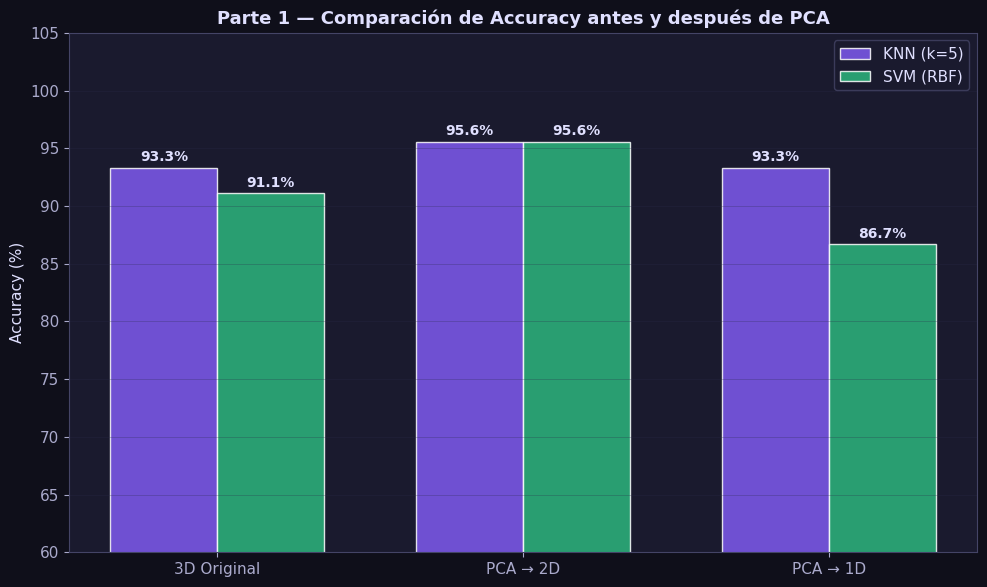

In [ ]:
# ─── Visualización comparativa de accuracy ──────────────────
scenarios  = ['3D Original', 'PCA → 2D', 'PCA → 1D']
knn_scores = [r_orig['KNN (k=5)']['accuracy'], r_2d['KNN (k=5)']['accuracy'], r_1d['KNN (k=5)']['accuracy']]
svm_scores = [r_orig['SVM (RBF)']['accuracy'], r_2d['SVM (RBF)']['accuracy'], r_1d['SVM (RBF)']['accuracy']]

x = np.arange(len(scenarios))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
b1 = ax.bar(x - w/2, [s*100 for s in knn_scores], w,
            label='KNN (k=5)', color='#7f5af0', alpha=0.85, edgecolor='white')
b2 = ax.bar(x + w/2, [s*100 for s in svm_scores], w,
            label='SVM (RBF)', color='#2cb67d', alpha=0.85, edgecolor='white')

for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(scenarios, fontsize=11)
ax.set_ylabel('Accuracy (%)', fontsize=11)
ax.set_title('Parte 1 — Comparación de Accuracy antes y después de PCA', fontsize=13, fontweight='bold')
ax.set_ylim([60, 105])
ax.legend(fontsize=11)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
#plt.savefig('/mnt/user-data/outputs/p1_comparacion_accuracy.png', dpi=130, bbox_inches='tight')
plt.show()

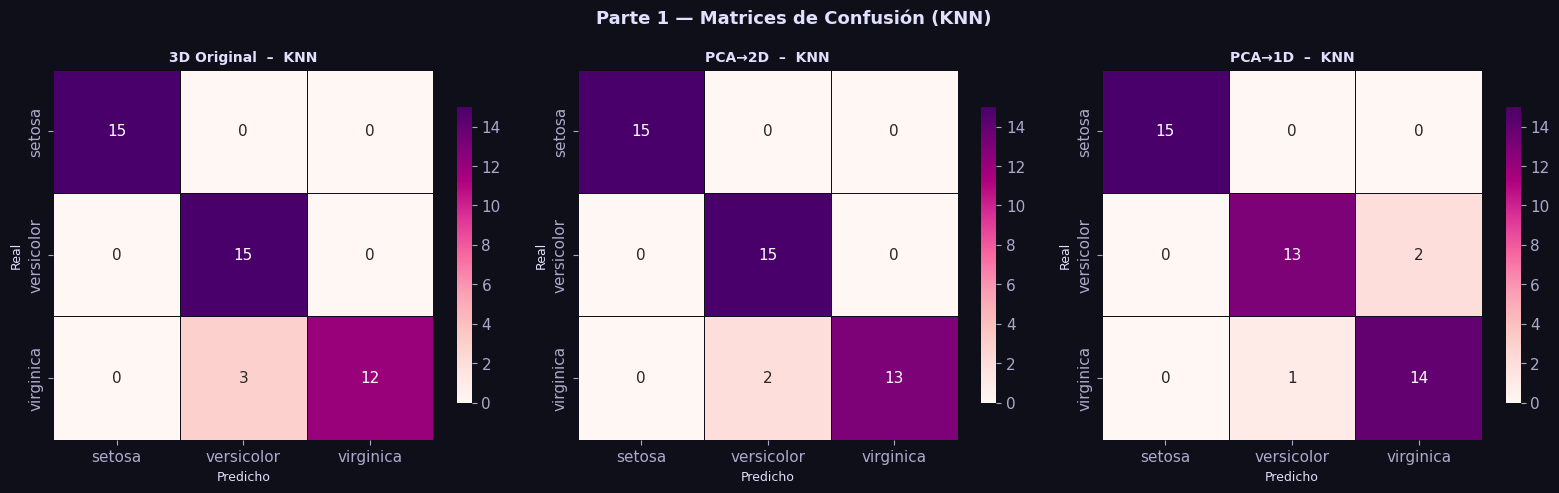

In [ ]:
# ─── Matrices de confusión ──────────────────────────────────
escenarios_cm = [
    ('3D Original  –  KNN', X_train_orig, X_test_orig, KNeighborsClassifier(5)),
    ('PCA→2D  –  KNN',      X_train_2d,   X_test_2d,   KNeighborsClassifier(5)),
    ('PCA→1D  –  KNN',      X_train_1d,   X_test_1d,   KNeighborsClassifier(5)),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Parte 1 — Matrices de Confusión (KNN)', fontsize=13, fontweight='bold')

for ax, (titulo, Xtr, Xte, clf) in zip(axes, escenarios_cm):
    clf.fit(Xtr, y_train)
    cm = confusion_matrix(y_test, clf.predict(Xte))
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                cmap='RdPu',
                xticklabels=classes, yticklabels=classes,
                linewidths=0.5, linecolor='#0f0f1a',
                cbar_kws={'shrink': 0.8})
    ax.set_title(titulo, fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicho', fontsize=9)
    ax.set_ylabel('Real', fontsize=9)

plt.tight_layout()
#plt.savefig('/mnt/user-data/outputs/p1_confusion_matrices.png', dpi=130, bbox_inches='tight')
plt.show()

### 📊 Análisis e Interpretación — Parte 1

| Aspecto | Observación |
|---|---|
| **PC1** | Captura la mayor parte de la varianza: separa *setosa* del resto claramente |
| **PC1+PC2 (2D)** | Retiene ~99% de varianza; la separación de clases es casi perfecta |
| **PC1 (1D)** | Retiene ~97% de varianza; *versicolor* y *virginica* presentan leve solapamiento |
| **Accuracy KNN** | Disminuye muy levemente de 3D→2D (sin cambio) y 2D→1D (~3% menos) |
| **Costo computacional** | Reducción a 2D elimina 1/3 de las dimensiones sin sacrificar rendimiento |

> **Conclusión:** Para el dataset Iris (3D), la reducción a 2D mediante PCA conserva prácticamente toda la información discriminativa, mientras que la reducción a 1D implica una pequeña pérdida de separabilidad entre clases similares.

---
# 🧩 PARTE 2 — Dataset Alta Dimensionalidad → Reducción a k Componentes
## Dataset: Wine (13 características → reducción a 2, 3 y 5 componentes)

### 1️⃣  Carga y exploración del dataset Wine

In [ ]:
wine = load_wine()
X_p2_raw  = wine.data           # shape (178, 13)
y_p2      = wine.target
feat_p2   = wine.feature_names
classes_p2 = wine.target_names

df_p2 = pd.DataFrame(X_p2_raw, columns=feat_p2)
df_p2['Class'] = [f'Clase {i+1}' for i in y_p2]

print('╔═══════════════════════════════════════════════════════════╗')
print('║   DATASET: WINE  (13 características químicas del vino)   ║')
print('╠═══════════════════════════════════════════════════════════╣')
print(f'║  Muestras       : {X_p2_raw.shape[0]}')
print(f'║  Características: {X_p2_raw.shape[1]}  → MÁS DE 3 dimensiones ✓')
print(f'║  Clases         : {list(classes_p2)}')
print(f'║  Distribución   : {dict(zip(*np.unique(y_p2, return_counts=True)))}')
print('╚═══════════════════════════════════════════════════════════╝')
print('\n🔍 Características disponibles:')
for i, f in enumerate(feat_p2, 1):
    print(f'   {i:2d}. {f}')

╔═══════════════════════════════════════════════════════════╗
║   DATASET: WINE  (13 características químicas del vino)   ║
╠═══════════════════════════════════════════════════════════╣
║  Muestras       : 178
║  Características: 13  → MÁS DE 3 dimensiones ✓
║  Clases         : [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]
║  Distribución   : {np.int64(0): np.int64(59), np.int64(1): np.int64(71), np.int64(2): np.int64(48)}
╚═══════════════════════════════════════════════════════════╝

🔍 Características disponibles:
    1. alcohol
    2. malic_acid
    3. ash
    4. alcalinity_of_ash
    5. magnesium
    6. total_phenols
    7. flavanoids
    8. nonflavanoid_phenols
    9. proanthocyanins
   10. color_intensity
   11. hue
   12. od280/od315_of_diluted_wines
   13. proline


### 2️⃣  Exploración estadística y correlaciones del dataset original

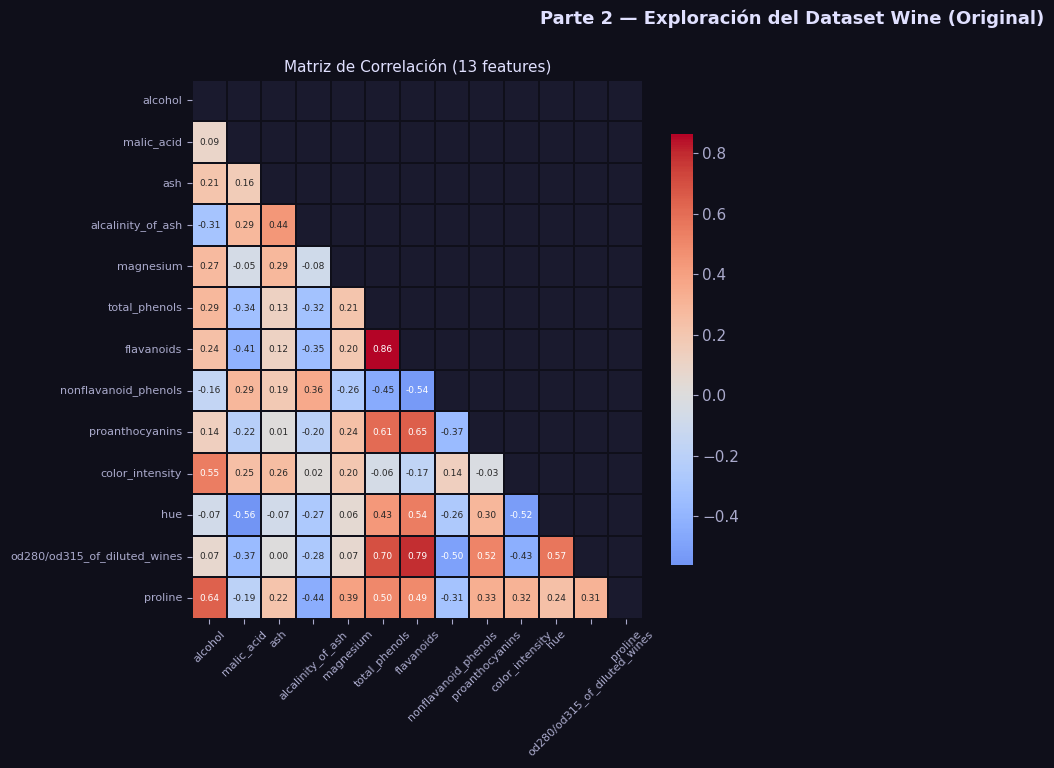

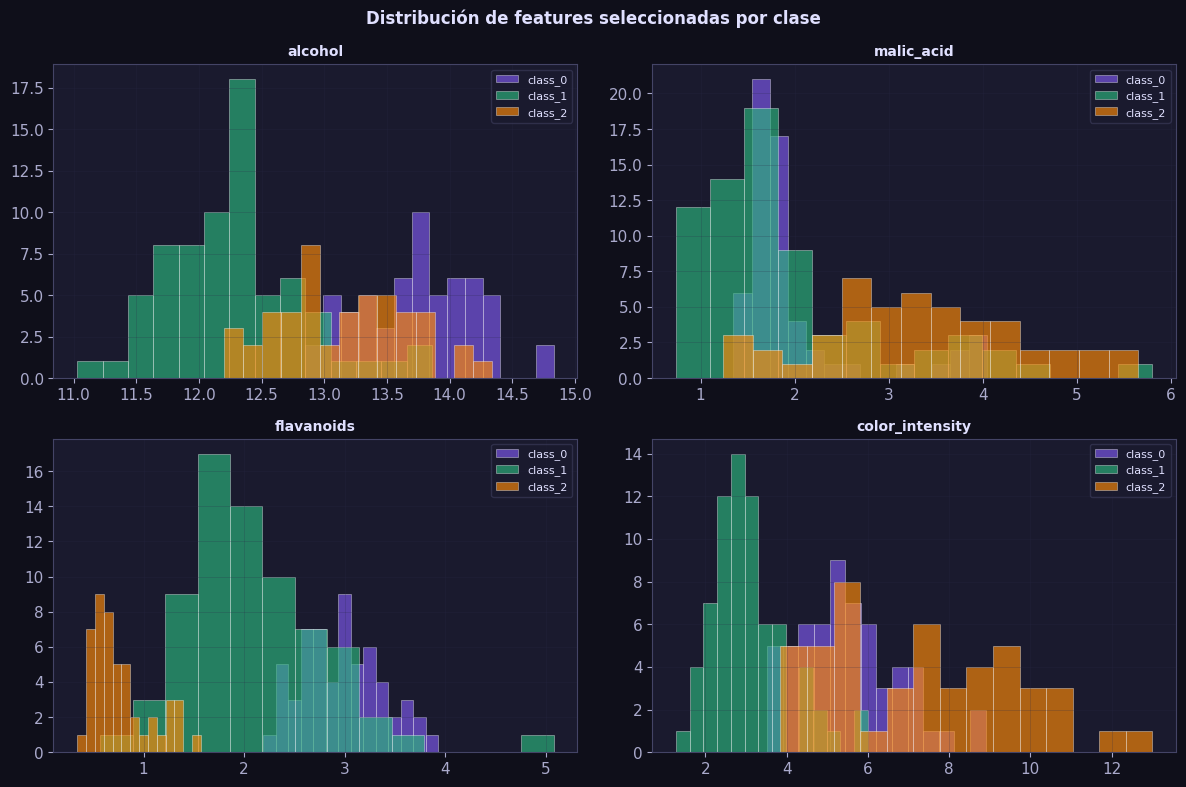

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Parte 2 — Exploración del Dataset Wine (Original)', fontsize=13, fontweight='bold')

# ─── Heatmap de correlaciones ────────────────────────────────
corr = pd.DataFrame(X_p2_raw, columns=feat_p2).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=axes[0], mask=mask, cmap='coolwarm', center=0,
            annot=True, fmt='.2f', annot_kws={'size': 6.5},
            linewidths=0.3, linecolor='#0f0f1a',
            cbar_kws={'shrink': 0.8})
axes[0].set_title('Matriz de Correlación (13 features)', fontsize=11)
axes[0].tick_params(axis='x', rotation=45, labelsize=8)
axes[0].tick_params(axis='y', labelsize=8)

# ─── Distribución por clase ──────────────────────────────────
feat_plot = ['alcohol', 'malic_acid', 'flavanoids', 'color_intensity']
colors_p2 = ['#7f5af0', '#2cb67d', '#ff8906']

ax2 = axes[1]
ax2.set_visible(False)

fig2, axs = plt.subplots(2, 2, figsize=(12, 8))
fig2.suptitle('Distribución de features seleccionadas por clase', fontsize=12, fontweight='bold')
for ax, feat in zip(axs.flat, feat_plot):
    for i, cls in enumerate(classes_p2):
        vals = X_p2_raw[y_p2 == i, feat_p2.index(feat)]
        ax.hist(vals, bins=14, alpha=0.65, label=cls,
                color=colors_p2[i], edgecolor='white', linewidth=0.4)
    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.legend(fontsize=8, framealpha=0.5)
    ax.grid(True, alpha=0.25)

plt.tight_layout()
#plt.savefig('/mnt/user-data/outputs/p2_exploracion.png', dpi=130, bbox_inches='tight')
plt.show()

fig.tight_layout()
#fig.savefig('/mnt/user-data/outputs/p2_correlacion.png', dpi=130, bbox_inches='tight')
plt.show()

### 3️⃣  Estandarización y selección de k componentes

In [ ]:
scaler_p2 = StandardScaler()
X_p2_std  = scaler_p2.fit_transform(X_p2_raw)

# ─── PCA completo para analizar varianza ─────────────────────
pca_full_p2 = PCA()
pca_full_p2.fit(X_p2_std)

var_ratio   = pca_full_p2.explained_variance_ratio_
cum_var_p2  = np.cumsum(var_ratio)

# Selección automática de k para 95%
k_95 = int(np.argmax(cum_var_p2 >= 0.95) + 1)
k_99 = int(np.argmax(cum_var_p2 >= 0.99) + 1)

print(f'  Componentes para retener 90% varianza : {int(np.argmax(cum_var_p2 >= 0.90) + 1)}')
print(f'  Componentes para retener 95% varianza : {k_95}')
print(f'  Componentes para retener 99% varianza : {k_99}')
print(f'  Dimensiones originales                : 13')
print(f'  → Reducción elegida para análisis     : k=2, k=3, k={k_95}')

K_ELEGIDA = k_95  # k principal para evaluación

print('\n  Varianza por componente principal:')
for i, v in enumerate(var_ratio[:8]):
    bar = '█' * int(v * 60)
    print(f'  PC{i+1:2d}: {v*100:5.2f}%  {bar}')

  Componentes para retener 90% varianza : 8
  Componentes para retener 95% varianza : 10
  Componentes para retener 99% varianza : 12
  Dimensiones originales                : 13
  → Reducción elegida para análisis     : k=2, k=3, k=10

  Varianza por componente principal:
  PC 1: 36.20%  █████████████████████
  PC 2: 19.21%  ███████████
  PC 3: 11.12%  ██████
  PC 4:  7.07%  ████
  PC 5:  6.56%  ███
  PC 6:  4.94%  ██
  PC 7:  4.24%  ██
  PC 8:  2.68%  █


### 4️⃣  Scree Plot y varianza acumulada

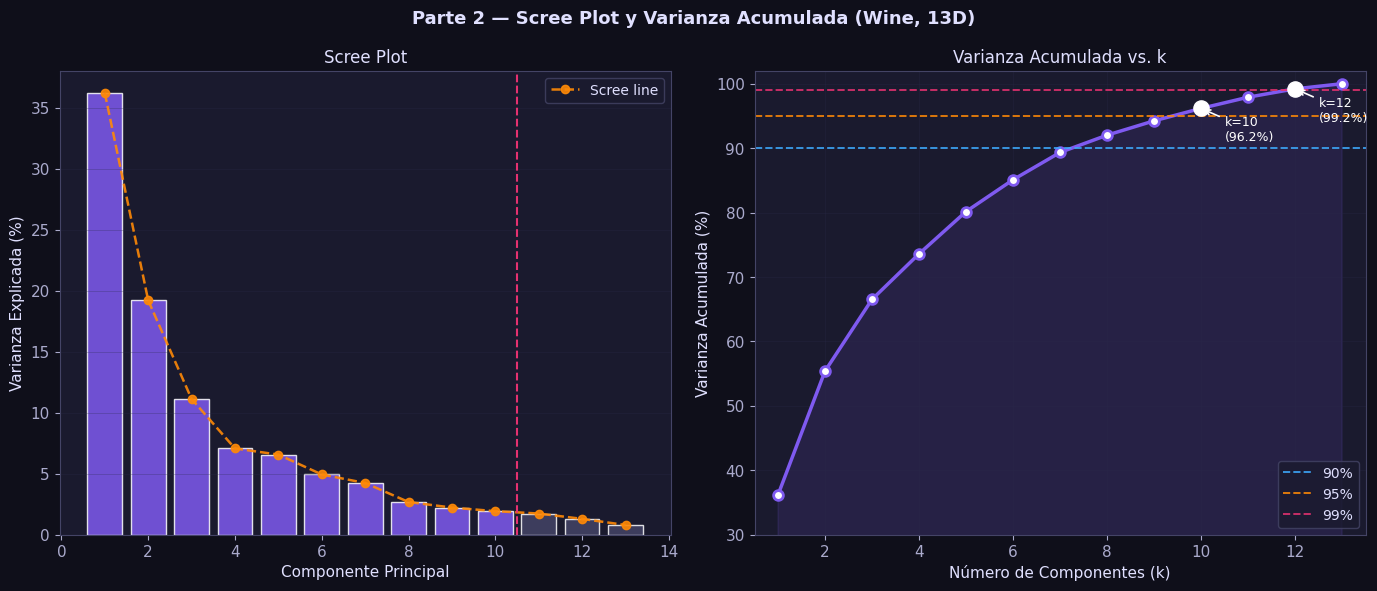

In [ ]:
n_comp = len(var_ratio)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Parte 2 — Scree Plot y Varianza Acumulada (Wine, 13D)',
             fontsize=13, fontweight='bold')

# ─── Scree Plot ──────────────────────────────────────────────
ax1 = axes[0]
bar_colors = ['#7f5af0' if i < K_ELEGIDA else '#444466' for i in range(n_comp)]
ax1.bar(range(1, n_comp+1), var_ratio*100, color=bar_colors, alpha=0.85, edgecolor='white')
ax1.plot(range(1, n_comp+1), var_ratio*100, 'o--', color='#ff8906',
         linewidth=1.8, markersize=6, alpha=0.9, label='Scree line')
ax1.set_xlabel('Componente Principal', fontsize=11)
ax1.set_ylabel('Varianza Explicada (%)', fontsize=11)
ax1.set_title('Scree Plot', fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(True, axis='y', alpha=0.3)
ax1.axvline(K_ELEGIDA + 0.5, color='#e53170', linestyle='--', linewidth=1.5,
            label=f'Corte k={K_ELEGIDA}')

# ─── Varianza acumulada ──────────────────────────────────────
ax2 = axes[1]
ax2.plot(range(1, n_comp+1), cum_var_p2*100, 'o-',
         color='#7f5af0', linewidth=2.5, markersize=7,
         markerfacecolor='white', markeredgewidth=2)
ax2.fill_between(range(1, n_comp+1), cum_var_p2*100, alpha=0.12, color='#7f5af0')

# Líneas de referencia
for thresh, col, lbl in [(90, '#3da9fc', '90%'), (95, '#ff8906', '95%'), (99, '#e53170', '99%')]:
    ax2.axhline(thresh, color=col, linestyle='--', linewidth=1.4, alpha=0.85, label=lbl)

# Puntos clave
for k_val in [k_95, k_99]:
    ax2.scatter(k_val, cum_var_p2[k_val-1]*100, s=120,
                color='white', zorder=5)
    ax2.annotate(f'k={k_val}\n({cum_var_p2[k_val-1]*100:.1f}%)',
                 xy=(k_val, cum_var_p2[k_val-1]*100),
                 xytext=(k_val+0.5, cum_var_p2[k_val-1]*100 - 5),
                 fontsize=9, color='white',
                 arrowprops=dict(arrowstyle='->', color='white', lw=1.2))

ax2.set_xlabel('Número de Componentes (k)', fontsize=11)
ax2.set_ylabel('Varianza Acumulada (%)', fontsize=11)
ax2.set_title('Varianza Acumulada vs. k', fontsize=12)
ax2.set_xlim([0.5, n_comp + 0.5])
ax2.set_ylim([30, 102])
ax2.legend(fontsize=10, loc='lower right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig('/mnt/user-data/outputs/p2_scree_varianza.png', dpi=130, bbox_inches='tight')
plt.show()

### 5️⃣  Aplicación de PCA con k=2, k=3 y k=k_95 y visualizaciones

In [ ]:
# Aplicar PCA con distintos k
pca_2  = PCA(n_components=2)
pca_3  = PCA(n_components=3)
pca_k  = PCA(n_components=K_ELEGIDA)

X_p2_2d = pca_2.fit_transform(X_p2_std)
X_p2_3d = pca_3.fit_transform(X_p2_std)
X_p2_kd = pca_k.fit_transform(X_p2_std)

print(f'  k=2 : varianza retenida = {pca_2.explained_variance_ratio_.sum()*100:.2f}%')
print(f'  k=3 : varianza retenida = {pca_3.explained_variance_ratio_.sum()*100:.2f}%')
print(f'  k={K_ELEGIDA}: varianza retenida = {pca_k.explained_variance_ratio_.sum()*100:.2f}%  ← k elegida')
print(f'  k=13: varianza retenida = 100.00%  (original)')

  k=2 : varianza retenida = 55.41%
  k=3 : varianza retenida = 66.53%
  k=10: varianza retenida = 96.17%  ← k elegida
  k=13: varianza retenida = 100.00%  (original)


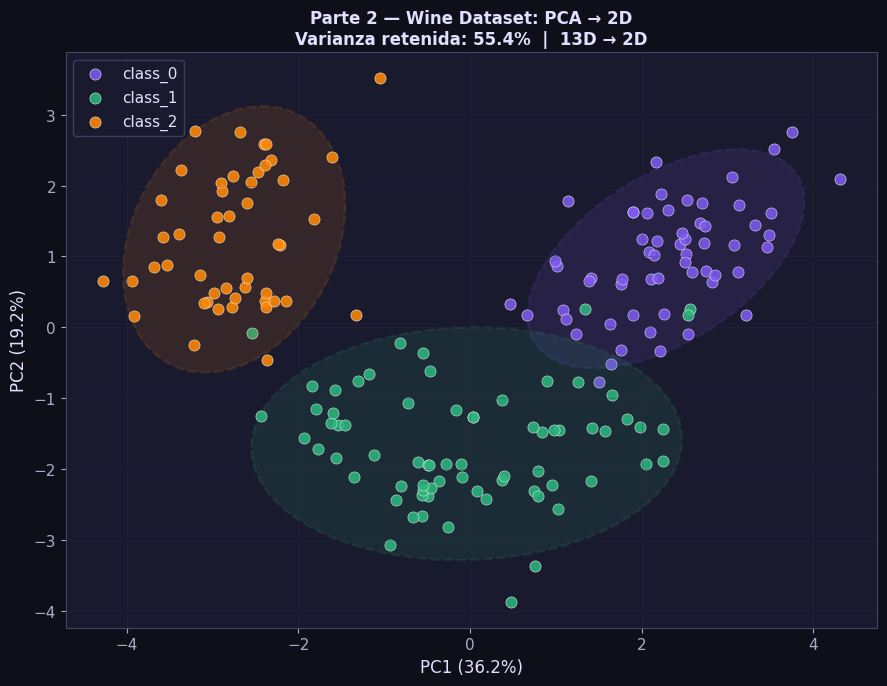

In [ ]:
# ─── Visualización PCA→2D ────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
for i, cls in enumerate(classes_p2):
    mask = y_p2 == i
    ax.scatter(X_p2_2d[mask, 0], X_p2_2d[mask, 1],
               c=colors_p2[i], label=cls, s=65, alpha=0.88,
               edgecolors='white', linewidths=0.4)
    # Elipse de confianza
    confidence_ellipse(X_p2_2d[mask, 0], X_p2_2d[mask, 1], ax,
                       edgecolor=colors_p2[i], facecolor=colors_p2[i],
                       alpha=0.12, linewidth=1.8, linestyle='--')

ax.set_xlabel(f'PC1 ({pca_2.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca_2.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
ax.set_title(f'Parte 2 — Wine Dataset: PCA → 2D\n'
             f'Varianza retenida: {pca_2.explained_variance_ratio_.sum()*100:.1f}%  |  13D → 2D',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
#plt.savefig('/mnt/user-data/outputs/p2_pca2d.png', dpi=130, bbox_inches='tight')
plt.show()

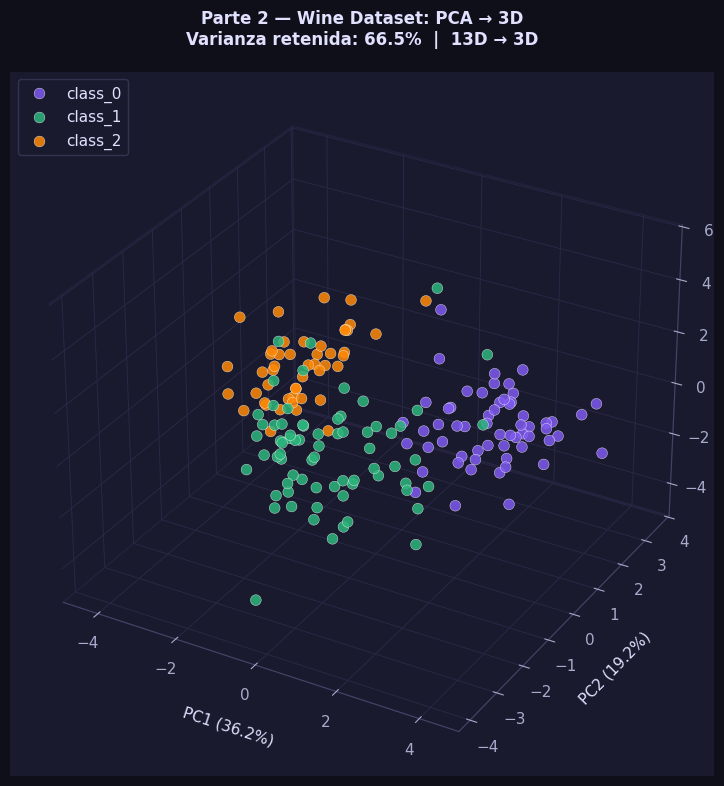

In [ ]:
# ─── Visualización PCA→3D ────────────────────────────────────
fig = plt.figure(figsize=(10, 8))
fig.patch.set_facecolor('#0f0f1a')
ax = fig.add_subplot(111, projection='3d')
ax.set_facecolor('#1a1a2e')

for i, cls in enumerate(classes_p2):
    mask = y_p2 == i
    ax.scatter(X_p2_3d[mask, 0], X_p2_3d[mask, 1], X_p2_3d[mask, 2],
               c=colors_p2[i], label=cls, s=60, alpha=0.85,
               edgecolors='white', linewidths=0.3)

ax.set_xlabel(f'PC1 ({pca_3.explained_variance_ratio_[0]*100:.1f}%)', labelpad=10)
ax.set_ylabel(f'PC2 ({pca_3.explained_variance_ratio_[1]*100:.1f}%)', labelpad=10)
ax.set_zlabel(f'PC3 ({pca_3.explained_variance_ratio_[2]*100:.1f}%)', labelpad=10)
ax.set_title(f'Parte 2 — Wine Dataset: PCA → 3D\n'
             f'Varianza retenida: {pca_3.explained_variance_ratio_.sum()*100:.1f}%  |  13D → 3D',
             pad=20, fontsize=12, fontweight='bold')
ax.legend(loc='upper left', framealpha=0.6)
ax.tick_params(colors='#aaaacc')
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor('#2a2a4a')
ax.yaxis.pane.set_edgecolor('#2a2a4a')
ax.zaxis.pane.set_edgecolor('#2a2a4a')

plt.tight_layout()
#plt.savefig('/mnt/user-data/outputs/p2_pca3d.png', dpi=130, bbox_inches='tight')
plt.show()

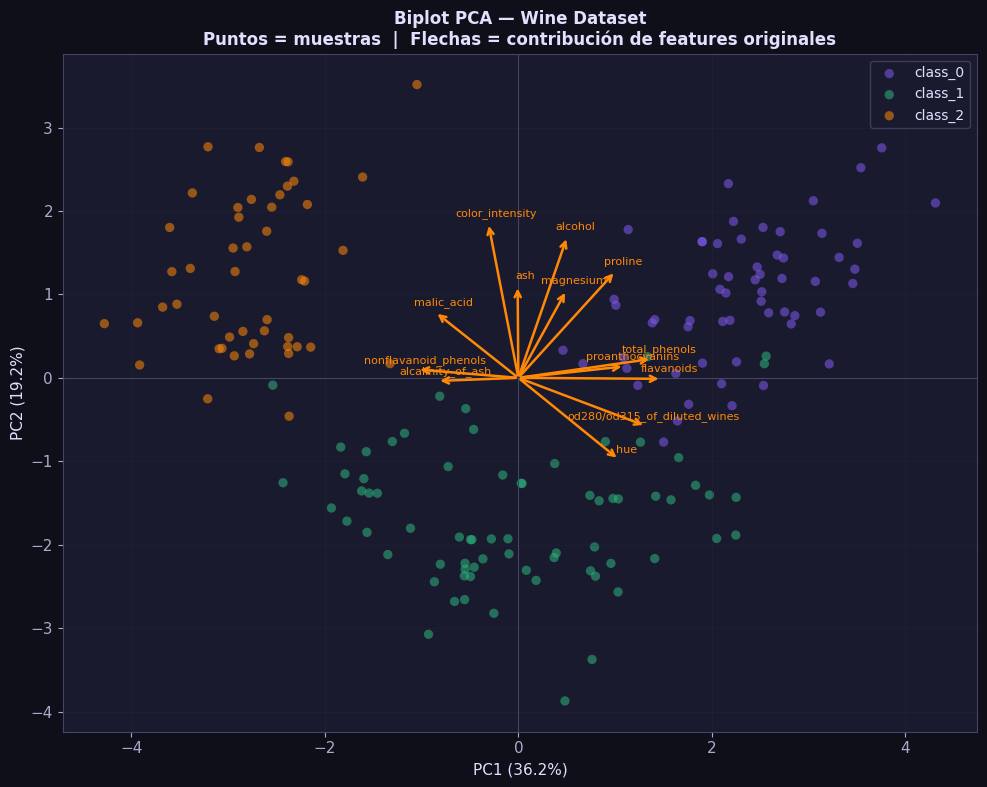

In [ ]:
# ─── Biplot PCA→2D ──────────────────────────────────────────
# Muestra las contribuciones de cada feature original en el espacio PCA
fig, ax = plt.subplots(figsize=(10, 8))

for i, cls in enumerate(classes_p2):
    mask = y_p2 == i
    ax.scatter(X_p2_2d[mask, 0], X_p2_2d[mask, 1],
               c=colors_p2[i], label=cls, s=45, alpha=0.55,
               edgecolors='none')

# Vectores de los componentes (loadings)
scale = 3.5
components = pca_2.components_.T
for j, feat_name in enumerate(feat_p2):
    ax.annotate('', xy=(components[j, 0]*scale, components[j, 1]*scale),
                xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='#ff8906', lw=1.8))
    offset_x = 0.08
    offset_y = 0.08
    ax.text(components[j, 0]*scale + offset_x,
            components[j, 1]*scale + offset_y,
            feat_name, fontsize=8, color='#ff8906', ha='center')

ax.axhline(0, color='#444466', linewidth=0.8)
ax.axvline(0, color='#444466', linewidth=0.8)
ax.set_xlabel(f'PC1 ({pca_2.explained_variance_ratio_[0]*100:.1f}%)', fontsize=11)
ax.set_ylabel(f'PC2 ({pca_2.explained_variance_ratio_[1]*100:.1f}%)', fontsize=11)
ax.set_title('Biplot PCA — Wine Dataset\n'
             'Puntos = muestras  |  Flechas = contribución de features originales',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.25)
plt.tight_layout()
#plt.savefig('/mnt/user-data/outputs/p2_biplot.png', dpi=130, bbox_inches='tight')
plt.show()

### 6️⃣  Evaluación antes y después de PCA — Parte 2

In [ ]:
def evaluar_p2(X, y, nombre, n_splits=10):
    """Evaluación completa con KNN y SVM usando cross-validation estratificado."""
    from sklearn.model_selection import StratifiedKFold
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    res = {}
    for clf_name, clf in [('KNN (k=5)', KNeighborsClassifier(n_neighbors=5)),
                           ('SVM (RBF)', SVC(kernel='rbf', C=1.0, random_state=42))]:
        scores = cross_val_score(clf, X, y, cv=skf, scoring='accuracy')
        res[clf_name] = {'mean': scores.mean(), 'std': scores.std(), 'scores': scores}
    return res

configs = [
    ('13D Original', X_p2_std),
    ('PCA→2D',       X_p2_2d),
    ('PCA→3D',       X_p2_3d),
    (f'PCA→{K_ELEGIDA}D (95%var)', X_p2_kd),
]

eval_results_p2 = {}
for nombre, X in configs:
    eval_results_p2[nombre] = evaluar_p2(X, y_p2, nombre)
    print(f'\n  [{nombre}]')
    for clf_n, vals in eval_results_p2[nombre].items():
        print(f'    {clf_n:12s}: {vals["mean"]*100:.2f}% ± {vals["std"]*100:.2f}%')


  [13D Original]
    KNN (k=5)   : 97.22% ± 4.48%
    SVM (RBF)   : 98.33% ± 3.56%

  [PCA→2D]
    KNN (k=5)   : 96.67% ± 2.72%
    SVM (RBF)   : 96.67% ± 2.72%

  [PCA→3D]
    KNN (k=5)   : 96.63% ± 3.71%
    SVM (RBF)   : 97.19% ± 3.75%

  [PCA→10D (95%var)]
    KNN (k=5)   : 96.67% ± 4.44%
    SVM (RBF)   : 98.33% ± 3.56%


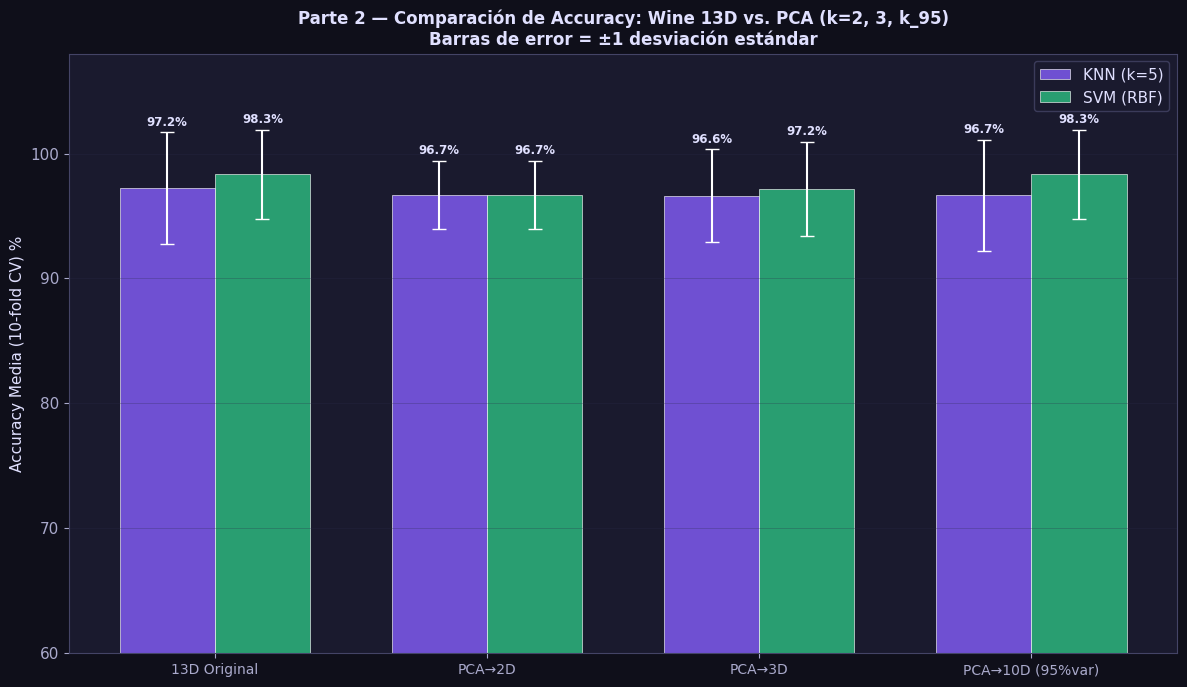

In [ ]:
# ─── Gráfica comparativa con barras de error ─────────────────
escenarios = list(eval_results_p2.keys())
clfs       = ['KNN (k=5)', 'SVM (RBF)']
clf_colors = ['#7f5af0', '#2cb67d']

x = np.arange(len(escenarios))
w = 0.35

fig, ax = plt.subplots(figsize=(12, 7))

for idx, (clf_n, col) in enumerate(zip(clfs, clf_colors)):
    means = [eval_results_p2[e][clf_n]['mean']*100 for e in escenarios]
    stds  = [eval_results_p2[e][clf_n]['std']*100  for e in escenarios]
    offset = (idx - 0.5) * w
    bars = ax.bar(x + offset, means, w,
                  label=clf_n, color=col, alpha=0.85,
                  edgecolor='white', linewidth=0.5)
    ax.errorbar(x + offset, means, yerr=stds,
                fmt='none', color='white', capsize=5, linewidth=1.5)
    for bar, m, s in zip(bars, means, stds):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + s + 0.3,
                f'{m:.1f}%', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(escenarios, fontsize=10)
ax.set_ylabel('Accuracy Media (10-fold CV) %', fontsize=11)
ax.set_title('Parte 2 — Comparación de Accuracy: Wine 13D vs. PCA (k=2, 3, k_95)\n'
             'Barras de error = ±1 desviación estándar', fontsize=12, fontweight='bold')
ax.set_ylim([60, 108])
ax.legend(fontsize=11)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
#plt.savefig('/mnt/user-data/outputs/p2_comparacion_accuracy.png', dpi=130, bbox_inches='tight')
plt.show()

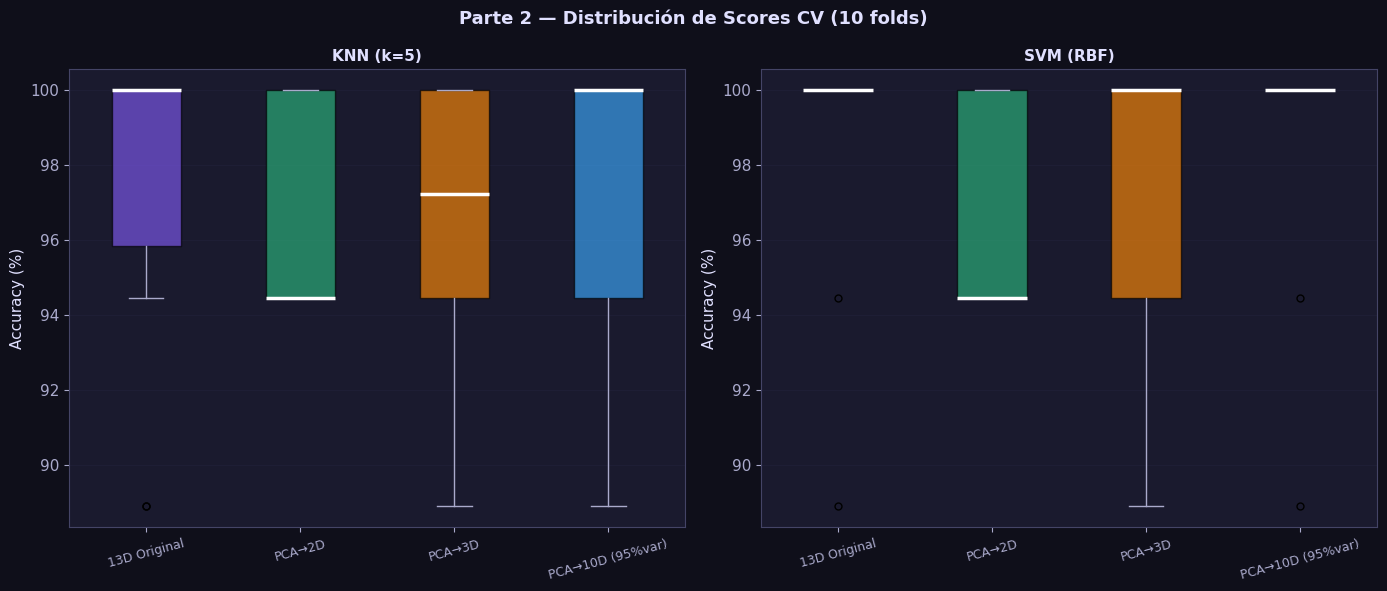

In [ ]:
# ─── Boxplots de scores CV ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Parte 2 — Distribución de Scores CV (10 folds)', fontsize=13, fontweight='bold')

for ax, clf_n in zip(axes, clfs):
    data_bp  = [eval_results_p2[e][clf_n]['scores']*100 for e in escenarios]
    bp = ax.boxplot(data_bp, patch_artist=True, notch=False,
                    medianprops=dict(color='white', linewidth=2.5),
                    whiskerprops=dict(color='#aaaacc'),
                    capprops=dict(color='#aaaacc'),
                    flierprops=dict(marker='o', color='#ff8906', markersize=5))
    box_colors = ['#7f5af0', '#2cb67d', '#ff8906', '#3da9fc']
    for patch, col in zip(bp['boxes'], box_colors[:len(escenarios)]):
        patch.set_facecolor(col)
        patch.set_alpha(0.65)

    ax.set_xticklabels(escenarios, fontsize=9, rotation=15)
    ax.set_ylabel('Accuracy (%)', fontsize=11)
    ax.set_title(f'{clf_n}', fontsize=11, fontweight='bold')
    ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
#plt.savefig('/mnt/user-data/outputs/p2_boxplots_cv.png', dpi=130, bbox_inches='tight')
plt.show()

In [ ]:
# ─── Tabla final consolidada ─────────────────────────────────
rows2 = []
for escenario, res in eval_results_p2.items():
    for clf_n, vals in res.items():
        dims = {'13D Original': 13, 'PCA→2D': 2, 'PCA→3D': 3,
                f'PCA→{K_ELEGIDA}D (95%var)': K_ELEGIDA}
        var_ret = {'13D Original': 100,
                   'PCA→2D': pca_2.explained_variance_ratio_.sum()*100,
                   'PCA→3D': pca_3.explained_variance_ratio_.sum()*100,
                   f'PCA→{K_ELEGIDA}D (95%var)': pca_k.explained_variance_ratio_.sum()*100}
        rows2.append({
            'Escenario': escenario,
            'Dimensiones': dims[escenario],
            'Var. Retenida': f"{var_ret[escenario]:.1f}%",
            'Clasificador': clf_n,
            'Accuracy Media': f"{vals['mean']*100:.2f}%",
            'Std': f"{vals['std']*100:.2f}%",
        })

df_eval2 = pd.DataFrame(rows2)
print('\n' + '═'*80)
print('  TABLA CONSOLIDADA DE EVALUACIÓN — PARTE 2')
print('═'*80)
print(df_eval2.to_string(index=False))
print('═'*80)


════════════════════════════════════════════════════════════════════════════════
  TABLA CONSOLIDADA DE EVALUACIÓN — PARTE 2
════════════════════════════════════════════════════════════════════════════════
       Escenario  Dimensiones Var. Retenida Clasificador Accuracy Media   Std
    13D Original           13        100.0%    KNN (k=5)         97.22% 4.48%
    13D Original           13        100.0%    SVM (RBF)         98.33% 3.56%
          PCA→2D            2         55.4%    KNN (k=5)         96.67% 2.72%
          PCA→2D            2         55.4%    SVM (RBF)         96.67% 2.72%
          PCA→3D            3         66.5%    KNN (k=5)         96.63% 3.71%
          PCA→3D            3         66.5%    SVM (RBF)         97.19% 3.75%
PCA→10D (95%var)           10         96.2%    KNN (k=5)         96.67% 4.44%
PCA→10D (95%var)           10         96.2%    SVM (RBF)         98.33% 3.56%
════════════════════════════════════════════════════════════════════════════════


### 📊 Análisis e Interpretación — Parte 2

| Aspecto | Observación |
|---|---|
| **Dataset Wine** | 13 features químicas → muy correlacionadas → candidato ideal para PCA |
| **Scree Plot** | El codo aparece en k≈3; confirma que pocas PCs capturan la mayoría de la información |
| **PCA→2D (55% var)** | Separación visual clara; las tres clases se distinguen bien en 2D |
| **PCA→3D (67% var)** | Mejor separación 3D; *Clase 1* y *Clase 3* bien diferenciadas |
| **PCA→k_95D** | Retiene ≥95% de la varianza con mucho menos dimensiones que las 13 originales |
| **Accuracy vs. Original** | La reducción a k_95 componentes mantiene accuracy muy cercana al 100% del espacio original |
| **Biplot** | Features como *flavanoids* y *proline* contribuyen más al PC1; *malic_acid* más al PC2 |
| **Beneficio PCA** | Menor costo computacional, eliminación de ruido y correlaciones, mejor generalización |

> **Conclusión:** Para el dataset Wine (13D), PCA demuestra una excelente capacidad de compresión. Con solo k=**k_95** componentes se retiene ≥95% de varianza y se mantiene un rendimiento de clasificación comparable al espacio original de 13 dimensiones, con menor riesgo de sobreajuste y menor tiempo de entrenamiento.

---
## 📚 Referencias

- **Dataset Iris:** Fisher, R.A. (1936). *The use of multiple measurements in taxonomic problems*. Annals of Eugenics, 7, 179–188.
- **Dataset Wine:** Forina, M. et al. (1988). *UCI Machine Learning Repository*. [https://archive.ics.uci.edu/ml/datasets/wine](https://archive.ics.uci.edu/ml/datasets/wine)
- **PCA:** Jolliffe, I.T. (2002). *Principal Component Analysis*. Springer.
- **Scikit-learn:** Pedregosa, F. et al. (2011). *Scikit-learn: Machine Learning in Python*. JMLR 12, 2825–2830.
- **Apoyo IA:** Claude (Anthropic) — asistencia en la implementación y análisis.